In [54]:
import warnings
warnings.filterwarnings('ignore')

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

In [56]:
df = pd.read_csv('/content/store_data.csv', header = None)

In [57]:
df.shape

(7501, 20)

In [58]:
transactions = []
for i in range(df.shape[0]):
    transactions.append(
        [str(df.values[i, j]) for j in range(df.shape[1]) if pd.notna(df.values[i, j])]
    )

In [59]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)

In [60]:
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

FP growth

In [61]:
frequent_itemsets = fpgrowth(df_encoded,
                             min_support=0.03,
                             use_colnames=True
                             )

In [62]:
frequent_itemsets

,support,itemsets
0,0.238368,(mineral water)
1,0.132116,(green tea)
2,0.076523,(low fat yogurt)
3,0.071457,(shrimp)
4,0.065858,(olive oil)
5,0.063325,(frozen smoothie)
6,0.047460,(honey)
7,0.042528,(salmon)
8,0.033329,(avocado)
9,0.031862,(cottage cheese)


**Association rule**

In [63]:
rules = association_rules(frequent_itemsets,
                          metric = "confidence",
                          min_threshold = 0.2
                          )

In [64]:
rules[
        ['antecedents',
         'consequents',
         'support',
         'confidence',
         'lift'
        ]
    ]


,antecedents,consequents,support,confidence,lift
0,(green tea),(mineral water),0.031063,0.235116,0.986357
1,(eggs),(mineral water),0.050927,0.283383,1.188845
2,(mineral water),(eggs),0.050927,0.213647,1.188845
3,(milk),(mineral water),0.047994,0.370370,1.553774
4,(mineral water),(milk),0.047994,0.201342,1.553774
5,(milk),(spaghetti),0.035462,0.273663,1.571779
6,(spaghetti),(milk),0.035462,0.203675,1.571779
7,(milk),(chocolate),0.032129,0.247942,1.513276
8,(milk),(eggs),0.030796,0.237654,1.322437
9,(eggs),(french fries),0.036395,0.202522,1.184961


**Top 10 Frequent Itemsets**

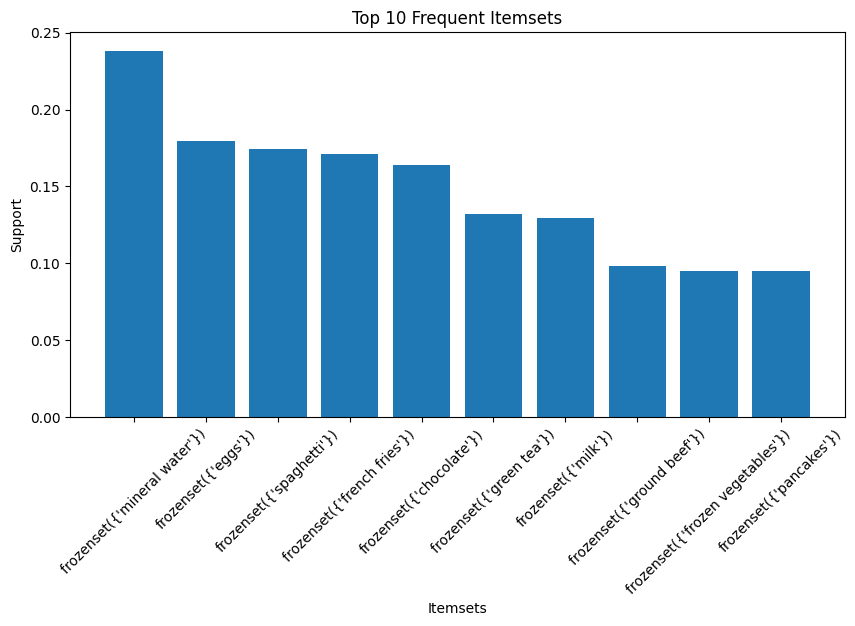

In [65]:
top10 = frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)
plt.figure(figsize=(10,5))
plt.bar(
    top10['itemsets'].astype(str),
    top10['support']
)
plt.xticks(rotation=45)
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.title("Top 10 Frequent Itemsets")
plt.show()

**Confidence vs Lift Scatter Plot**

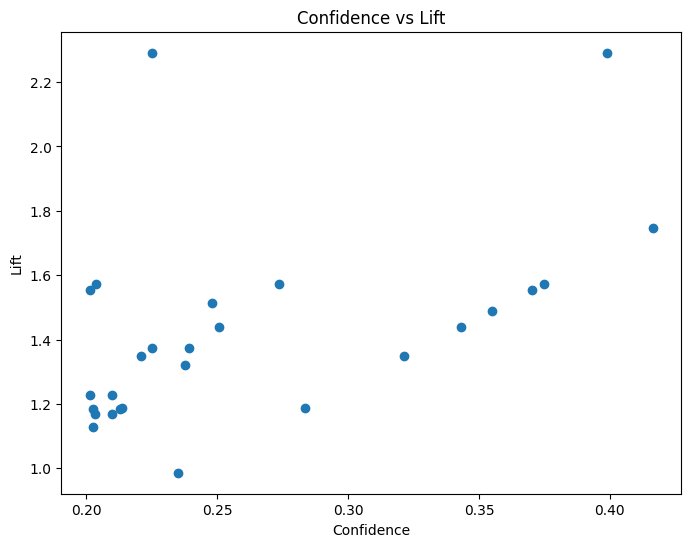

In [66]:
plt.figure(figsize=(8,6))
plt.scatter(
    rules['confidence'],
    rules['lift']
)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Confidence vs Lift")
plt.show()